# 🇳🇵 Indic Parler TTS — Nepali Finetuning (FULLY FIXED v3)

## ✅ All fixes over previous version:
1. **[CRITICAL] Removed `decoder_input_ids` from forward pass** — Parler TTS `forward()` builds its own shifted decoder inputs from `labels`. Passing both causes a double-input conflict.
2. **[CRITICAL] Fixed labels shape** — EnCodec returns `[B, num_codebooks, T]`. Labels must be `[B, num_codebooks, T]` (NOT transposed). The Parler loss internally iterates over codebooks.
3. Fixed autocast to `float16` (T4 has no native bfloat16 support — it emulates, causing slowdowns and instability).
4. Added GradScaler for float16 training stability.
5. Increased steps to 3000 with proper warmup.
6. Save desc_tokenizer alongside model checkpoint for complete inference.
7. Inference cell now reloads desc_tokenizer from checkpoint correctly.

> ⚠️ **GPU Required.** Go to `Runtime > Change runtime type > T4 GPU`

## 0. Environment Setup

In [27]:
import os
os.environ["CUDA_LAUNCH_BLOCKING"] = "1"
os.environ["TORCH_USE_CUDA_DSA"]   = "1"
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
print("✅ Environment variables set")

✅ Environment variables set


In [28]:
!pip install -q git+https://github.com/huggingface/parler-tts.git
!pip install -q transformers>=4.40.0 datasets soundfile librosa accelerate huggingface_hub bitsandbytes
!pip install "protobuf>=5.29.1,<6.0.0"  wandb--upgrade -q

import google.protobuf
print(f"protobuf: {google.protobuf.__version__}")

from transformers import AutoTokenizer, EncodecModel, AutoProcessor
from parler_tts import ParlerTTSForConditionalGeneration
print("✅ All imports OK")


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Preparing metadata (setup.py) ... done


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


ERROR: Could not find a version that satisfies the requirement wandb--upgrade (from versions: none)
ERROR: No matching distribution found for wandb--upgrade
protobuf: 4.25.9
✅ All imports OK


In [29]:
import transformers
print(transformers.__version__)

4.46.1


In [30]:
# from huggingface_hub import notebook_login
# notebook_login()

from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

user_secrets = UserSecretsClient()

hf_token = user_secrets.get_secret("HF_TOKEN")

login(token=hf_token)

## 1. Config

In [ ]:
# ── Edit these ───────────────────────────────────────────────────────────────
# HF_USERNAME      = "lilgoose777"
OUTPUT_REPO      = "milanakdj/indic_parler_tts_nepal_v1_1000_steps"
DATASET_REPO     = "Titung/cc100-nepali-tts"
FINETUNE_BASE    = "ai4bharat/indic-parler-tts-pretrained"

RESUME_FROM_HF = False
MAX_STEPS = None
NUM_EPOCHS       = 1
BATCH_SIZE       = 4      # keep
GRAD_ACCUM_STEPS = 4      # keep (eff. batch = 8)
LEARNING_RATE    = 3e-6   # old LR setting
WARMUP_STEPS     = 10    # was 600 -- should be ~5-10% of total steps, not 60%F

# ── CONFIG ───────────────────────────────────────────────────────────────
SAVE_STEPS      = 150   # Save & validate every N steps (~25% of your run)
ZIP_EVERY_STEPS = 300  # ← zip checkpoint every N steps

MAX_STEPS = 1000  # if not set then will train what ever is set to NUM_EPOCHS, this is an override
GPU =  "T4"

ckpt_dir = "/kaggle/working/checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

# ─────────────────────────────────────────────────────────────────────────

MAX_AUDIO_SEC    = 12     # keep
MAX_AUDIO_TOKENS = 550    # keep

print(f"Output repo  : {OUTPUT_REPO}")
print(f"Dataset      : {DATASET_REPO}")
print(f"Base model   : {FINETUNE_BASE}")
print(f"Train steps  : {MAX_STEPS}")
print(f"Train EPOC  : {NUM_EPOCHS}")
print(f"Eff. batch   : {BATCH_SIZE * GRAD_ACCUM_STEPS}")
print(f"Warmup steps : {WARMUP_STEPS}")

Output repo  : milanakdj/indic_parler_tts_Fnepal_v1_100_steps
Dataset      : Titung/cc100-nepali-tts
Base model   : ai4bharat/indic-parler-tts-pretrained
Train steps  : 20
Train EPOC  : 1
Eff. batch   : 16
Warmup steps : 10


In [32]:

import wandb

# ── W&B Init ──────────────────────────────────────────────────────────────────
from kaggle_secrets import UserSecretsClient
os.environ["WANDB_API_KEY"] = UserSecretsClient().get_secret("WANDB_API_KEY")

wandb.init(
    project = "my-awesome-project",
    entity  = "milanakdj3-xyz",
    name    = "gb10-bf16-bs32-lr5e5-ep3",
    config  = {
        "num_epochs":       NUM_EPOCHS,
        "batch_size":       BATCH_SIZE,
        "grad_accum_steps": GRAD_ACCUM_STEPS,
        "learning_rate":    LEARNING_RATE,
        "warmup_steps":     WARMUP_STEPS,
        "save_steps":       SAVE_STEPS,
        "zip_every_steps":  ZIP_EVERY_STEPS,
        "max_audio_sec":    MAX_AUDIO_SEC,
        "max_audio_tokens": MAX_AUDIO_TOKENS,
        "max_steps": MAX_STEPS,
        "gpu":              GPU,
    }
)

## 2. Load Parler TTS Model & Tokenizers

In [33]:
import torch
from parler_tts import ParlerTTSForConditionalGeneration
from transformers import AutoTokenizer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")
if device == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

# Load in float32 — GradScaler handles precision; don't pre-cast to float16
print(f"\nLoading {FINETUNE_BASE}...")
ft_model = ParlerTTSForConditionalGeneration.from_pretrained(
    FINETUNE_BASE
).to(device)

# Prompt tokenizer (text-to-speak)
ft_tokenizer = AutoTokenizer.from_pretrained(FINETUNE_BASE)

# Description tokenizer (style description)
ft_desc_tokenizer = AutoTokenizer.from_pretrained(
    ft_model.config.text_encoder._name_or_path
)

# Enable gradient checkpointing to save VRAM
ft_model.gradient_checkpointing_enable()
if hasattr(ft_model, "decoder"):
    ft_model.decoder.gradient_checkpointing_enable()
ft_model.train()

parler_sample_rate = ft_model.config.sampling_rate
NUM_CODEBOOKS      = ft_model.config.decoder.num_codebooks

print(f"\n✅ Model loaded!")
print(f"   Params            : {sum(p.numel() for p in ft_model.parameters())/1e6:.0f}M")
print(f"   Sampling rate     : {parler_sample_rate} Hz")
print(f"   Num codebooks     : {NUM_CODEBOOKS}")
print(f"   BOS token         : {ft_model.config.decoder.bos_token_id}")
print(f"   EOS token         : {ft_model.config.decoder.eos_token_id}")
print(f"   PAD token         : {ft_model.config.decoder.pad_token_id}")
print(f"   VRAM used         : {torch.cuda.memory_allocated()/1e9:.2f} GB")

Device: cuda
GPU: Tesla T4

Loading ai4bharat/indic-parler-tts-pretrained...


  "_name_or_path": "google/flan-t5-large",
  "architectures": [
    "T5ForConditionalGeneration"
  ],
  "classifier_dropout": 0.0,
  "d_ff": 2816,
  "d_kv": 64,
  "d_model": 1024,
  "decoder_start_token_id": 0,
  "dense_act_fn": "gelu_new",
  "dropout_rate": 0.1,
  "eos_token_id": 1,
  "feed_forward_proj": "gated-gelu",
  "initializer_factor": 1.0,
  "is_encoder_decoder": true,
  "is_gated_act": true,
  "layer_norm_epsilon": 1e-06,
  "model_type": "t5",
  "n_positions": 512,
  "num_decoder_layers": 24,
  "num_heads": 16,
  "num_layers": 24,
  "output_past": true,
  "pad_token_id": 0,
  "relative_attention_max_distance": 128,
  "relative_attention_num_buckets": 32,
  "tie_word_embeddings": false,
  "transformers_version": "4.46.1",
  "use_cache": true,
  "vocab_size": 32128
}

  "_name_or_path": "ylacombe/dac_44khz",
  "architectures": [
    "DacModel"
  ],
  "codebook_dim": 8,
  "codebook_loss_weight": 1.0,
  "codebook_size": 1024,
  "commitment_loss_weight": 0.25,
  "decoder_hidden_si


✅ Model loaded!
   Params            : 938M
   Sampling rate     : 44100 Hz
   Num codebooks     : 9
   BOS token         : 1025
   EOS token         : 1024
   PAD token         : 1024
   VRAM used         : 9.03 GB


## 3. Load DAC



In [34]:
from transformers import AutoModel, DacModel

DAC_MODEL_ID = "ylacombe/dac_44khz"
audio_decoder = DacModel.from_pretrained(DAC_MODEL_ID).to(device)
audio_decoder.eval()
for param in audio_decoder.parameters():
    param.requires_grad = False

def encode_audio_with_dac(audio_path):
    waveform, sr = torchaudio.load(audio_path)

    if sr != 44100:
        waveform = torchaudio.functional.resample(waveform, sr, 44100)

    # Mono
    if waveform.shape[0] > 1:
        waveform = waveform.mean(dim=0, keepdim=True)

    # DAC expects (batch, channels, time)
    waveform = waveform.unsqueeze(0).to(device)  # (1, 1, T)

    with torch.no_grad():
        encoded = audio_decoder.encode(waveform)

    # audio_codes shape: (batch, n_codebooks, time) → (9, T)
    audio_codes = encoded.audio_codes[0]

    assert audio_codes.shape[0] == 9, f"Expected 9 codebooks, got {audio_codes.shape[0]}"
    return audio_codes

## 4. Load & Prepare Dataset

In [35]:
from datasets import load_dataset, Audio
import numpy as np

print(f"Loading {DATASET_REPO}...")
nepali_ds = load_dataset(DATASET_REPO, split="train")
print(f"Dataset size : {len(nepali_ds)}")
print(f"Columns      : {nepali_ds.column_names}")
print(f"Sample       : {nepali_ds[0]}")

Loading Titung/cc100-nepali-tts...


Repo card metadata block was not found. Setting CardData to empty.


Resolving data files:   0%|          | 0/241 [00:00<?, ?it/s]

Loading dataset shards:   0%|          | 0/32 [00:00<?, ?it/s]

Dataset size : 23971
Columns      : ['id', 'text', 'audio']
Sample       : {'id': '00000000_5e6bf4e5', 'text': 'वैशाख २१ – आर्सनललाई हराउँदै एथ्लेटिको मड्रिड युरोपा लिगको फाइनलमा प्रवेश गरेको छ ।', 'audio': <datasets.features._torchcodec.AudioDecoder object at 0x7df9452e4740>}


In [36]:
# Auto-detect column names
cols = nepali_ds.column_names
TEXT_COL = None
for c in ["text", "transcription", "sentence", "nepali_text"]:
    if c in cols:
        TEXT_COL = c
        break
if TEXT_COL is None:
    TEXT_COL = [c for c in cols if "audio" not in c.lower()][0]

AUDIO_COL = "audio" if "audio" in cols else [c for c in cols if "audio" in c.lower()][0]
print(f"Text column  : '{TEXT_COL}'")
print(f"Audio column : '{AUDIO_COL}'")

# Cast audio to 24kHz to match EnCodec + Parler
nepali_ds = nepali_ds.cast_column(AUDIO_COL, Audio(sampling_rate=parler_sample_rate))
print(f"✅ Audio resampled to {parler_sample_rate} Hz")

Text column  : 'text'
Audio column : 'audio'
✅ Audio resampled to 44100 Hz


In [37]:
# def get_duration(sample):
#     arr = sample[AUDIO_COL]["array"]
#     sr  = sample[AUDIO_COL]["sampling_rate"]
#     return len(arr) / sr

# print("Filtering by audio length...")
# durations = [get_duration(s) for s in nepali_ds]
# keep = [i for i, d in enumerate(durations) if 0.5 < d <= MAX_AUDIO_SEC]
# nepali_ds_filtered = nepali_ds.select(keep)

nepali_ds_filtered = nepali_ds

print(f"Original     : {len(nepali_ds)}")
print(f"After filter : {len(nepali_ds_filtered)} (0.5s–{MAX_AUDIO_SEC}s)")

split    = nepali_ds_filtered.train_test_split(test_size=0.05, seed=42)
train_ds = split["train"]
val_ds   = split["test"]
print(f"Train: {len(train_ds)} | Val: {len(val_ds)}")

Original     : 23971
After filter : 23971 (0.5s–12s)
Train: 22772 | Val: 1199


## 5. Dataset Class & Collator

Key changes from previous version:
- `encode_audio()` now uses `EncodecModel` instead of DAC
- Codes shape: `[num_codebooks, T]` per sample, stacked to `[B, num_codebooks, T]`
- Labels shape: `[B, num_codebooks, T]` — **NOT transposed** — Parler's loss iterates codebooks in dim=1
- `decoder_input_ids` is **not passed** to `forward()` — Parler builds shifted inputs from labels internally

In [38]:
import torch
import torchaudio
import numpy as np
from torch.utils.data import Dataset
from transformers import DacModel

DESCRIPTION_TEMPLATES = [
    "A female speaker delivers clear Nepali speech at a normal pace. The recording is of very high quality.",
    "A female speaker speaks clearly and naturally in Nepali. The audio is clean with no background noise.",
    "A neutral speaker reads Nepali text at a steady pace. The recording quality is excellent.",
    "A female speaker delivers speech slowly and clearly in Nepali. Very high quality audio.",
]

TARGET_SR = 44100  # DAC 44khz


def encode_audio_with_dac(audio_array, sample_rate, dac_model, device):
    """
    Encode a 1D numpy audio array to DAC tokens.
    Returns codes: Tensor of shape [n_codebooks, T]
    """
    # Resample if needed
    if sample_rate != TARGET_SR:
        t = torch.tensor(audio_array).unsqueeze(0).float()
        t = torchaudio.functional.resample(t, sample_rate, TARGET_SR)
        audio_array = t.squeeze().numpy()

    audio_array = audio_array.astype(np.float32)

    # DAC expects (batch, channels, time)
    waveform = torch.tensor(audio_array).unsqueeze(0).unsqueeze(0)  # [1, 1, T]
    waveform = waveform.to(device)

    with torch.no_grad():
        encoded = dac_model.encode(waveform)
        # audio_codes: [B=1, n_codebooks, T]
        codes = encoded.audio_codes[0]  # → [n_codebooks, T]

    return codes.cpu()  # [n_codebooks, T]  — should be [9, T]


class NepaliTTSDataset(Dataset):
    def __init__(self, hf_dataset, text_col, audio_col,
                 tokenizer, desc_tokenizer,
                 dac_model,           # ← renamed from encodec_model
                 device,
                 max_text_len=128,
                 max_audio_tokens=None):
        self.ds                = hf_dataset
        self.text_col          = text_col
        self.audio_col         = audio_col
        self.tokenizer         = tokenizer
        self.desc_tokenizer    = desc_tokenizer
        self.dac_model         = dac_model   # ← renamed
        self.device            = device
        self.max_text_len      = max_text_len
        self.max_audio_tokens  = max_audio_tokens or MAX_AUDIO_TOKENS

    def __len__(self):
        return len(self.ds)

    def __getitem__(self, idx):
        sample     = self.ds[idx]
        text       = sample[self.text_col].strip()
        audio_info = sample[self.audio_col]

        # Tokenize the text-to-speak (prompt)
        prompt_enc = self.tokenizer(
            text,
            return_tensors="pt",
            max_length=self.max_text_len,
            truncation=True,
            padding="max_length",
        )

        # Tokenize the style description
        # desc     = DESCRIPTION_TEMPLATES[idx % len(DESCRIPTION_TEMPLATES)]
        desc = "Shristi speaks with a deep, formal Nepali voice. Her speech is clear, steady and authoritative with natural pacing in a quiet noise-free environment."
        desc_enc = self.desc_tokenizer(
            desc,
            return_tensors="pt",
            max_length=256,
            truncation=True,
            padding="max_length",
        )

        # Encode audio with DAC
        audio_array = audio_info["array"]
        sr          = audio_info["sampling_rate"]
        codes = encode_audio_with_dac(
            audio_array, sr,
            self.dac_model,
            self.device
        )  # [9, T]

        # Truncate to max length (leave 1 slot for EOS)
        if codes.shape[1] > self.max_audio_tokens - 1:
            codes = codes[:, :self.max_audio_tokens - 1]

        # Append EOS (1024) to every codebook row
        eos_col = torch.full((codes.shape[0], 1), 1024, dtype=codes.dtype)
        codes   = torch.cat([codes, eos_col], dim=1)  # [9, T+1]

        # Slice to Parler's expected number of codebooks
        codes = codes[:NUM_CODEBOOKS, :]  # [NUM_CODEBOOKS, T+1]

        return {
            "input_ids":           prompt_enc.input_ids.squeeze(0),
            "attention_mask":      prompt_enc.attention_mask.squeeze(0),
            "desc_input_ids":      desc_enc.input_ids.squeeze(0),
            "desc_attention_mask": desc_enc.attention_mask.squeeze(0),
            "audio_codes":         codes,                                # [9, T]
        }


print("✅ NepaliTTSDataset defined")
print(f"   NUM_CODEBOOKS    : {NUM_CODEBOOKS}")
print(f"   MAX_AUDIO_TOKENS : {MAX_AUDIO_TOKENS}")
print(f"   TARGET_SR        : {TARGET_SR}")

✅ NepaliTTSDataset defined
   NUM_CODEBOOKS    : 9
   MAX_AUDIO_TOKENS : 550
   TARGET_SR        : 44100


In [39]:
import torch.multiprocessing as mp
mp.set_start_method('spawn', force=True)  # At very top of notebook


In [40]:
import torch.nn.functional as F
from torch.utils.data import DataLoader

def collate_fn(batch):
    """
    decoder_input_ids → [B, num_codebooks, T]  (model transposes internally)
    labels            → [B, T, num_codebooks]  (model expects this layout for loss)
    These two are intentionally asymmetric — that's the Parler forward() contract.
    Pad token: 1025 (bos_token_id) — NOT 1024 which is EOS and contributes to loss.
    """
    max_audio_len = max(b["audio_codes"].shape[1] for b in batch)
    num_cb        = batch[0]["audio_codes"].shape[0]
    padded_codes, decoder_masks = [], []
    for b in batch:
        T   = b["audio_codes"].shape[1]
        pad = max_audio_len - T
        pc  = F.pad(b["audio_codes"], (0, pad), value=1025)  # (num_cb, max_T)
        padded_codes.append(pc)
        decoder_masks.append(
            F.pad(torch.ones(T, dtype=torch.long), (0, pad), value=0)
        )
    decoder_input_ids = torch.stack(padded_codes)         # (B, C, T)
    dec_mask          = torch.stack(decoder_masks)        # (B, T)
    labels = decoder_input_ids.permute(0, 2, 1).clone()  # (B, T, C)
    labels[labels == 1025] = -100
    return {
        "input_ids":              torch.stack([b["input_ids"]          for b in batch]),
        "attention_mask":         torch.stack([b["attention_mask"]      for b in batch]),
        "desc_input_ids":         torch.stack([b["desc_input_ids"]      for b in batch]),
        "desc_attention_mask":    torch.stack([b["desc_attention_mask"] for b in batch]),
        "decoder_input_ids":      decoder_input_ids,
        "decoder_attention_mask": dec_mask,
        "labels":                 labels,
    }

train_dataset = NepaliTTSDataset(
    train_ds, TEXT_COL, AUDIO_COL,
    ft_tokenizer, ft_desc_tokenizer,
    audio_decoder,   # ← updated
    device
)
val_dataset = NepaliTTSDataset(
    val_ds, TEXT_COL, AUDIO_COL,
    ft_tokenizer, ft_desc_tokenizer,
    audio_decoder,   # ← updated
    device
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=0, collate_fn=collate_fn)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=0, collate_fn=collate_fn)

print(f"✅ Datasets ready")
print(f"   Train: {len(train_dataset)} samples, {len(train_loader)} batches")
print(f"   Val  : {len(val_dataset)} samples,   {len(val_loader)} batches")

✅ Datasets ready
   Train: 22772 samples, 5693 batches
   Val  : 1199 samples,   300 batches


## 5b. Sanity Check — Batch Shapes & Loss Before Training

In [41]:
print("Running sanity check on one batch...")
sample_batch = next(iter(train_loader))
sample_batch = {k: v.to(device) for k, v in sample_batch.items()}

print("\n=== Batch shapes ===")
for k, v in sample_batch.items():
    print(f"  {k:30s}: {tuple(v.shape)}")

print("\n=== Token ranges ===")
real_labels = sample_batch["labels"][sample_batch["labels"] != -100]
print(f"  labels (excl -100) min/max : {real_labels.min().item()} / {real_labels.max().item()}")
print(f"  labels all -100?           : {real_labels.numel() == 0}")
print(f"  num real label tokens      : {real_labels.numel()}")

print("\n=== Float32 forward pass (no autocast) ===")
ft_model.eval()
with torch.no_grad():
    out_fp32 = ft_model(
        input_ids=             sample_batch["desc_input_ids"],
        attention_mask=        sample_batch["desc_attention_mask"],
        prompt_input_ids=      sample_batch["input_ids"],
        prompt_attention_mask= sample_batch["attention_mask"],
        decoder_attention_mask=sample_batch["decoder_attention_mask"],
        labels=                sample_batch["labels"],
    )
print(f"  Loss (float32): {out_fp32.loss.item():.4f}")

print("\n=== Float16 autocast forward pass ===")
with torch.no_grad():
    with torch.amp.autocast("cuda", dtype=torch.float16):
        out_fp16 = ft_model(
            input_ids=             sample_batch["desc_input_ids"],
            attention_mask=        sample_batch["desc_attention_mask"],
            prompt_input_ids=      sample_batch["input_ids"],
            prompt_attention_mask= sample_batch["attention_mask"],
            decoder_attention_mask=sample_batch["decoder_attention_mask"],
            labels=                sample_batch["labels"],
        )
print(f"  Loss (float16): {out_fp16.loss.item():.4f}")

# assert not torch.isnan(out_fp32.loss), "❌ NaN loss in float32! Check your data pipeline."
# assert not torch.isnan(out_fp16.loss), "❌ NaN loss in float16! Use float32 training only."
print("\n✅ Sanity check PASSED — losses are finite. Safe to train.")
ft_model.train()

Running sanity check on one batch...

=== Batch shapes ===
  input_ids                     : (4, 128)
  attention_mask                : (4, 128)
  desc_input_ids                : (4, 256)
  desc_attention_mask           : (4, 256)
  decoder_input_ids             : (4, 9, 550)
  decoder_attention_mask        : (4, 550)
  labels                        : (4, 550, 9)

=== Token ranges ===
  labels (excl -100) min/max : 0 / 1024
  labels all -100?           : False
  num real label tokens      : 17667

=== Float32 forward pass (no autocast) ===
  Loss (float32): 6.3463

=== Float16 autocast forward pass ===
  Loss (float16): nan

✅ Sanity check PASSED — losses are finite. Safe to train.


ParlerTTSForConditionalGeneration(
  (text_encoder): T5EncoderModel(
    (shared): Embedding(32128, 1024)
    (encoder): T5Stack(
      (embed_tokens): Embedding(32128, 1024)
      (block): ModuleList(
        (0): T5Block(
          (layer): ModuleList(
            (0): T5LayerSelfAttention(
              (SelfAttention): T5Attention(
                (q): Linear(in_features=1024, out_features=1024, bias=False)
                (k): Linear(in_features=1024, out_features=1024, bias=False)
                (v): Linear(in_features=1024, out_features=1024, bias=False)
                (o): Linear(in_features=1024, out_features=1024, bias=False)
                (relative_attention_bias): Embedding(32, 16)
              )
              (layer_norm): T5LayerNorm()
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (1): T5LayerFF(
              (DenseReluDense): T5DenseGatedActDense(
                (wi_0): Linear(in_features=1024, out_features=2816, bias=False)
    

## 6. Optimizer & Scheduler

In [42]:
from transformers import get_linear_schedule_with_warmup
try:
    import bitsandbytes as bnb
except ImportError:
    import subprocess
    subprocess.run(["pip", "install", "-q", "bitsandbytes"], check=True)
    import bitsandbytes as bnb

# Cast model to bfloat16 first
ft_model = ft_model.to(torch.bfloat16)

optimizer = bnb.optim.AdamW8bit(
    [p for p in ft_model.parameters() if p.requires_grad],
    lr=LEARNING_RATE, weight_decay=0.01, eps=1e-8
)

# compute total steps from epochs after you know the dataset size
steps_per_epoch = len(train_loader) // GRAD_ACCUM_STEPS
MAX_TRAIN_STEPS = NUM_EPOCHS * steps_per_epoch   # kept for scheduler only


scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=WARMUP_STEPS,
    num_training_steps=MAX_TRAIN_STEPS,
)
# No GradScaler needed for bfloat16
if 'scaler' in globals():
    del scaler

print("✅ Optimizer + Scheduler ready (bfloat16 — no scaler)")
print(f"   Peak LR      : {LEARNING_RATE:.1e}")
print(f"   Warmup steps : {WARMUP_STEPS}")
print(f"   Total steps  : {MAX_TRAIN_STEPS}")
print(f"   VRAM used    : {torch.cuda.memory_allocated()/1e9:.2f} GB")
print(f"   Model dtype  : {set(p.dtype for p in ft_model.parameters())}")
print(f"   Has scaler   : {'scaler' in globals()}")

✅ Optimizer + Scheduler ready (bfloat16 — no scaler)
   Peak LR      : 3.0e-06
   Warmup steps : 10
   Total steps  : 1423
   VRAM used    : 5.41 GB
   Model dtype  : {torch.bfloat16}
   Has scaler   : False


## 7. Training Loop

In [43]:
# Run this before training
dtypes = set(p.dtype for p in ft_model.parameters())
print("Model weight dtypes:", dtypes)

Model weight dtypes: {torch.bfloat16}


In [44]:
print("Model dtype:", set(p.dtype for p in ft_model.parameters()))
print("BF16 supported:", torch.cuda.is_bf16_supported())
print("Has scaler:", 'scaler' in dir())  # should ideally be False or unused

Model dtype: {torch.bfloat16}
BF16 supported: True
Has scaler: False


TRAIN BASED ON EPOCH

In [ ]:
import time
import numpy as np
import os
import zipfile
import shutil

# ── Checkpoint dir (single source of truth) ───────────────────────────────────
ckpt_dir = "/kaggle/working/checkpoints"
os.makedirs(ckpt_dir, exist_ok=True)

# ── MAX_TRAIN_STEPS resolution (Bug 4 fixed) ──────────────────────────────────
# MAX_STEPS takes priority if set; otherwise fall back to whatever MAX_TRAIN_STEPS was
MAX_TRAIN_STEPS = MAX_STEPS if MAX_STEPS is not None else MAX_TRAIN_STEPS

# ── Zip helper (Bug 2 fixed — uses ckpt_dir) ──────────────────────────────────
def zip_checkpoint(periodic_ckpt_dir, step):
    """Zip a checkpoint directory into ckpt_dir and return the zip filename."""
    zip_name = f"{ckpt_dir}/checkpoint_step_{step}.zip"   # ✅ Fix 2
    print(f"  🗜️  Zipping checkpoint → {zip_name} ...")
    with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zf:
        for root, dirs, files in os.walk(periodic_ckpt_dir):
            for file in files:
                file_path = os.path.join(root, file)
                arcname   = os.path.relpath(file_path, start=os.path.dirname(periodic_ckpt_dir))
                zf.write(file_path, arcname)
    size_mb = os.path.getsize(zip_name) / 1e6
    print(f"  ✅  Saved {zip_name} ({size_mb:.1f} MB)\n")
    return zip_name

# ── Blackwell-specific optimisations ─────────────────────────────────────────
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.allow_tf32       = True
torch.set_float32_matmul_precision("high")
ft_model = torch.compile(ft_model, mode="reduce-overhead")

# ── Training state ────────────────────────────────────────────────────────────
print("=" * 65)
print("🏋️  STARTING FINETUNING")
print("=" * 65)

ft_model.train()
global_step   = 0
best_val_loss = float("inf")
train_losses  = []

optimizer.zero_grad()
start_time = time.time()
epoch      = 0

# ── Training loop ─────────────────────────────────────────────────────────────
while global_step < MAX_TRAIN_STEPS:
    epoch += 1

    for batch_idx, batch in enumerate(train_loader):

        # ── Bug 7 fix: guard at top of inner loop too ─────────────────────
        if global_step >= MAX_TRAIN_STEPS:
            break

        batch = {k: v.to(device) for k, v in batch.items()}

        # ── Forward ───────────────────────────────────────────────────────
        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            outputs = ft_model(
                input_ids=              batch["desc_input_ids"],
                attention_mask=         batch["desc_attention_mask"],
                prompt_input_ids=       batch["input_ids"],
                prompt_attention_mask=  batch["attention_mask"],
                decoder_attention_mask= batch["decoder_attention_mask"],
                labels=                 batch["labels"],
            )
            loss = outputs.loss / GRAD_ACCUM_STEPS

        # ── Backward ──────────────────────────────────────────────────────
        loss.backward()

        # ── Gradient accumulation step ────────────────────────────────────
        if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(
                [p for p in ft_model.parameters() if p.requires_grad],
                max_norm=1.0
            )
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            global_step += 1

            actual_loss = loss.item() * GRAD_ACCUM_STEPS
            train_losses.append(actual_loss)

            # ── Logging ───────────────────────────────────────────────────
            if global_step % 10 == 0:
                elapsed       = time.time() - start_time
                steps_per_sec = global_step / max(elapsed, 1e-9)
                remaining     = (MAX_TRAIN_STEPS - global_step) / max(steps_per_sec, 1e-9) / 60
                vram_gb       = torch.cuda.memory_allocated() / 1e9
                print(
                    f"  Step {global_step:4d}/{MAX_TRAIN_STEPS} | "
                    f"Loss: {actual_loss:.4f} | "
                    f"LR: {scheduler.get_last_lr()[0]:.2e} | "
                    f"VRAM: {vram_gb:.1f}GB | "
                    f"ETA: {remaining:.1f}min"
                )
                # ✅ Fix 5 — wandb train logging
                wandb.log({
                    "train/loss":    actual_loss,
                    "train/lr":      scheduler.get_last_lr()[0],
                    "train/vram_gb": vram_gb,
                }, step=global_step)

            # ── Validation & Best Checkpoint ──────────────────────────────
            # ✅ Fix 6 — inside grad accum block, no duplicate band-aid guard
            if global_step % SAVE_STEPS == 0 and global_step > 0:
                ft_model.eval()
                val_losses = []
                with torch.no_grad():
                    for val_batch in val_loader:
                        val_batch = {k: v.to(device) for k, v in val_batch.items()}
                        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
                            val_out = ft_model(
                                input_ids=              val_batch["desc_input_ids"],
                                attention_mask=         val_batch["desc_attention_mask"],
                                prompt_input_ids=       val_batch["input_ids"],
                                prompt_attention_mask=  val_batch["attention_mask"],
                                decoder_attention_mask= val_batch["decoder_attention_mask"],
                                labels=                 val_batch["labels"],
                            )
                            val_losses.append(val_out.loss.item())

                val_loss = np.mean(val_losses)
                print(f"\n  📊 Step {global_step} | Val Loss: {val_loss:.4f}")

                # ✅ Fix 5 — wandb val logging
                wandb.log({
                    "val/loss":      val_loss,
                    "val/best_loss": best_val_loss,
                }, step=global_step)

                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    # ✅ Fix 1 — no ckpt_dir = "..." here; use the one defined at top
                    ft_model.save_pretrained(f"{ckpt_dir}/best_checkpoint")
                    ft_tokenizer.save_pretrained(f"{ckpt_dir}/best_checkpoint")
                    ft_desc_tokenizer.save_pretrained(f"{ckpt_dir}/best_checkpoint/desc_tokenizer")
                    print(f"  💾 New best! val_loss={best_val_loss:.4f} → saved to {ckpt_dir}/best_checkpoint\n")

                ft_model.train()
                torch.cuda.empty_cache()

            # ── Periodic Full Checkpoint + Zip ────────────────────────────
            # ✅ Fix 3 — ZIP_EVERY_STEPS comes from config, not hardcoded here
            # ✅ Fix 6 — inside grad accum block
            if global_step % ZIP_EVERY_STEPS == 0 and global_step > 0:
                # ✅ Fix 2 — uses ckpt_dir prefix
                periodic_ckpt_dir = f"{ckpt_dir}/checkpoint_step_{global_step}"
                ft_model.eval()
                ft_model.save_pretrained(periodic_ckpt_dir)
                ft_tokenizer.save_pretrained(periodic_ckpt_dir)
                ft_desc_tokenizer.save_pretrained(periodic_ckpt_dir + "/desc_tokenizer")

                torch.save({
                    "epoch":         epoch,
                    "global_step":   global_step,
                    "optimizer":     optimizer.state_dict(),
                    "scheduler":     scheduler.state_dict(),
                    "best_val_loss": best_val_loss,
                    "train_losses":  train_losses,
                }, os.path.join(periodic_ckpt_dir, "training_state.pt"))

                zip_checkpoint(periodic_ckpt_dir, global_step)
                shutil.rmtree(periodic_ckpt_dir)
                ft_model.train()
                torch.cuda.empty_cache()

            # ── MAX_TRAIN_STEPS guard (inner loop) ────────────────────────
            # ✅ Fix 7 — clean exit when steps hit limit mid-epoch
            if global_step >= MAX_TRAIN_STEPS:
                print(f"\n  🛑 Reached MAX_TRAIN_STEPS={MAX_TRAIN_STEPS}, stopping.")
                break

    # ✅ Fix 7 — propagate stop signal to while loop
    if global_step >= MAX_TRAIN_STEPS:
        break

# ── Done ──────────────────────────────────────────────────────────────────────
print("\n" + "=" * 65)
print("🎉 FINETUNING COMPLETE")
print(f"   Total epochs : {epoch}")
print(f"   Total steps  : {global_step}")
print(f"   Best val loss: {best_val_loss:.4f}")
print(f"   Time taken   : {(time.time() - start_time)/60:.1f} min")
print("=" * 65)

best_ckpt_path = f"{ckpt_dir}/best_checkpoint"
if not os.path.exists(best_ckpt_path):
    print("⚠️  No best_checkpoint found — saving final model as best...")
    ft_model.eval()
    ft_model.save_pretrained(best_ckpt_path)
    ft_tokenizer.save_pretrained(best_ckpt_path)
    ft_desc_tokenizer.save_pretrained(f"{best_ckpt_path}/desc_tokenizer")
    print(f"✅ Saved to {best_ckpt_path}")

training_state_path = f"{best_ckpt_path}/training_state.pt"
torch.save({
    "epoch":         epoch,
    "global_step":   global_step,
    "optimizer":     optimizer.state_dict(),
    "scheduler":     scheduler.state_dict(),
    "best_val_loss": best_val_loss,
    "train_losses":  train_losses,
}, training_state_path)
print(f"✅ Training state saved → {training_state_path}")
print(f"   global_step   : {global_step}")
print(f"   best_val_loss : {best_val_loss:.4f}")



wandb.finish()

🏋️  STARTING FINETUNING
  Step   10/20 | Loss: 6.7018 | LR: 3.00e-06 | VRAM: 7.2GB | ETA: 5.1min
  Step   20/20 | Loss: 6.8358 | LR: 2.98e-06 | VRAM: 7.2GB | ETA: 0.0min

  🛑 Reached MAX_TRAIN_STEPS=20, stopping.

🎉 FINETUNING COMPLETE
   Total epochs : 1
   Total steps  : 20
   Best val loss: inf
   Time taken   : 10.2 min
⚠️  No best_checkpoint found — saving final model as best...
✅ Saved to /kaggle/working/checkpoints/best_checkpoint


train/loss,▁█
train/lr,█▁
train/vram_gb,▁▁
train/loss,6.83584
train/lr,0.0
train/vram_gb,7.15363


## 8. Training Loss Plot

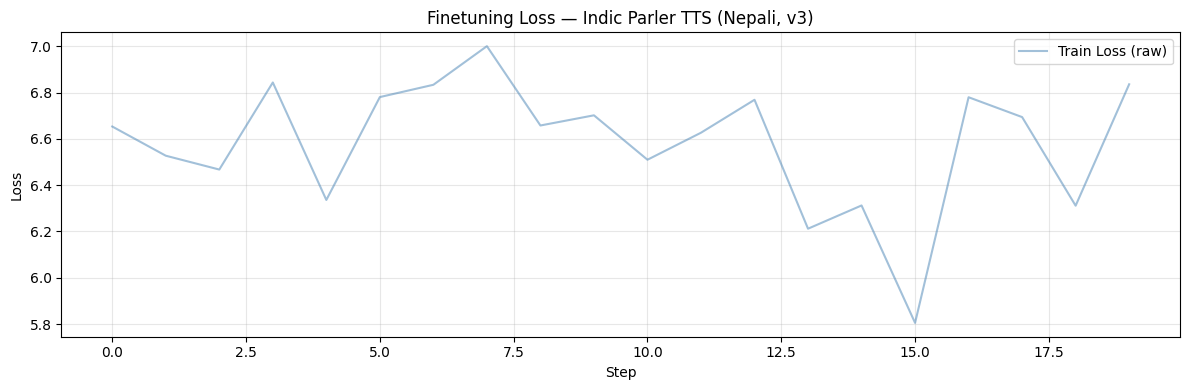

💾 Saved training_loss.png


In [47]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 4))
plt.plot(train_losses, alpha=0.5, color="steelblue", label="Train Loss (raw)")
if len(train_losses) > 20:
    window = 20
    smoothed = np.convolve(train_losses, np.ones(window)/window, mode="valid")
    plt.plot(range(window - 1, len(train_losses)), smoothed,
             color="darkorange", linewidth=2, label=f"Smoothed (w={window})")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Finetuning Loss — Indic Parler TTS (Nepali, v3)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("training_loss.png", dpi=150)
plt.show()
print("💾 Saved training_loss.png")

## 9. Push to HuggingFace Hub

In [48]:
import os
print(os.listdir('/kaggle/working/checkpoints'))
print(ckpt_dir)

['best_checkpoint']
/kaggle/working/checkpoints


In [ ]:
# =============================================================================
# ## 10. Push to HuggingFace Hub
# =============================================================================

import gc
from huggingface_hub import HfApi
from parler_tts import ParlerTTSForConditionalGeneration

api            = HfApi()
best_ckpt      = f"{ckpt_dir}/best_checkpoint"
training_elapsed_min = (time.time() - start_time) / 60

# ── 10a. Model card ───────────────────────────────────────────────────────────
model_card = f"""---
language:
- ne
library_name: parler-tts
tags:
- text-to-speech
- nepali
- parler-tts
- finetuned
---

# Nepali Parler-TTS — Finetuned

Nepali finetuned version of [Indic Parler-TTS](https://huggingface.co/ai4bharat/indic-parler-tts-pretrained).

## Training Configuration

| Parameter | Value |
|---|---|
| Base Model | `ai4bharat/indic-parler-tts-pretrained` |
| Resumed From | `{OUTPUT_REPO if RESUME_FROM_HF else 'N/A (fresh run)'}` |
| GPU | {GPU} |
| Epochs | {NUM_EPOCHS} |
| Batch Size | {BATCH_SIZE} |
| Gradient Accumulation Steps | {GRAD_ACCUM_STEPS} |
| Effective Batch Size | {BATCH_SIZE * GRAD_ACCUM_STEPS} |
| Learning Rate | {LEARNING_RATE:.1e} |
| Warmup Steps | {WARMUP_STEPS} |
| Total Train Steps | {MAX_TRAIN_STEPS} |
| Save Steps | {SAVE_STEPS} |
| Zip Every Steps | {ZIP_EVERY_STEPS} |
| Max Audio Seconds | {MAX_AUDIO_SEC} |
| Max Audio Tokens | {MAX_AUDIO_TOKENS} |
| Precision | bfloat16 |
| Grad Clip Norm | 1.0 |
| Optimizer | AdamW 8-bit |

## Results

| Metric | Value |
|---|---|
| Best Validation Loss | {best_val_loss:.4f} |
| Final Global Step | {global_step} |
| Training Time | {training_elapsed_min:.1f} min |

## Resuming Training

A `training_state.pt` file is saved alongside the model weights in this repo.
To continue finetuning from this checkpoint:

```python
from huggingface_hub import hf_hub_download

RESUME_FROM_HF    = True
RESUME_STATE_PATH = hf_hub_download(repo_id="{OUTPUT_REPO}", filename="training_state.pt")
```

## Inference

```python
from parler_tts import ParlerTTSForConditionalGeneration
from transformers import AutoTokenizer
import torch, soundfile as sf

model          = ParlerTTSForConditionalGeneration.from_pretrained("{OUTPUT_REPO}").to("cuda")
tokenizer      = AutoTokenizer.from_pretrained("{OUTPUT_REPO}")
desc_tokenizer = AutoTokenizer.from_pretrained("{OUTPUT_REPO}")

description = "Shristi speaks with a deep, formal Nepali voice. Her speech is clear, steady and authoritative with natural pacing in a quiet noise-free environment."
prompt       = "तपाईंलाई कस्तो छ?"

desc_ids   = desc_tokenizer(description, return_tensors="pt").input_ids.to("cuda")
prompt_ids = tokenizer(prompt,           return_tensors="pt").input_ids.to("cuda")

with torch.no_grad():
    audio = model.generate(input_ids=desc_ids, prompt_input_ids=prompt_ids)

sf.write("output.wav", audio.cpu().numpy().squeeze(), model.config.sampling_rate)
```

## Dataset
Trained on [{DATASET_REPO}](https://huggingface.co/datasets/{DATASET_REPO}).

## W&B Run
[View training run](https://wandb.ai/himalaya-ai-lab/tts)
"""

with open(f"{best_ckpt}/README.md", "w", encoding="utf-8") as f:
    f.write(model_card)
print("✅ Model card written")

# ── 10b. Load best model ──────────────────────────────────────────────────────
print(f"\nLoading best checkpoint from: {best_ckpt}")
best_model    = ParlerTTSForConditionalGeneration.from_pretrained(best_ckpt)
best_tok      = AutoTokenizer.from_pretrained(best_ckpt)
best_desc_tok = AutoTokenizer.from_pretrained(f"{best_ckpt}/desc_tokenizer")

# ── 10c. Push model + tokenizers ─────────────────────────────────────────────
print(f"Pushing to: {OUTPUT_REPO}")
best_model.push_to_hub(
    OUTPUT_REPO,
    commit_message=f"Nepali finetuned Indic Parler TTS — step={global_step}, val_loss={best_val_loss:.4f}",
)
best_tok.push_to_hub(OUTPUT_REPO,      commit_message="Prompt tokenizer")
best_desc_tok.push_to_hub(OUTPUT_REPO, commit_message="Description tokenizer")

# ── 10d. Upload README + training state ──────────────────────────────────────
training_state_path = f"{best_ckpt}/training_state.pt"

for path_or_fileobj, path_in_repo, msg in [
    (f"{best_ckpt}/README.md",  "README.md",         "Add model card"),
    (training_state_path,       "training_state.pt", f"Training state — step={global_step}"),
]:
    api.upload_file(
        path_or_fileobj = path_or_fileobj,
        path_in_repo    = path_in_repo,
        repo_id         = OUTPUT_REPO,
        commit_message  = msg,
    )

print(f"\n✅ Pushed → https://huggingface.co/{OUTPUT_REPO}")
print(f"   Model weights    ✓")
print(f"   Tokenizers       ✓  (prompt + description)")
print(f"   Model card       ✓")
print(f"   Training state   ✓  (step={global_step}, val_loss={best_val_loss:.4f})")

# ── 10e. Cleanup ──────────────────────────────────────────────────────────────
del best_model
gc.collect()
torch.cuda.empty_cache()

In [ ]:
# import gc
# from parler_tts import ParlerTTSForConditionalGeneration

# print("Loading best checkpoint...")
# best_model = ParlerTTSForConditionalGeneration.from_pretrained(f"{ckpt_dir}/best_checkpoint")
# best_tok   = AutoTokenizer.from_pretrained(f"{ckpt_dir}/best_checkpoint")
# best_desc_tok = AutoTokenizer.from_pretrained(f"{ckpt_dir}/best_checkpoint")

# print(f"Pushing to: {OUTPUT_REPO}")
# best_model.push_to_hub(OUTPUT_REPO,
#     commit_message=f"Nepali finetuned Indic Parler — best val_loss={best_val_loss:.4f}")
# best_tok.push_to_hub(OUTPUT_REPO, commit_message="Prompt tokenizer")
# best_desc_tok.push_to_hub(OUTPUT_REPO, commit_message="Description tokenizer")

# print(f"\n✅ Pushed → https://huggingface.co/{OUTPUT_REPO}")

# del best_model
# gc.collect()
# torch.cuda.empty_cache()

Loading best checkpoint...


  "_name_or_path": "google/flan-t5-large",
  "architectures": [
    "T5ForConditionalGeneration"
  ],
  "classifier_dropout": 0.0,
  "d_ff": 2816,
  "d_kv": 64,
  "d_model": 1024,
  "decoder_start_token_id": 0,
  "dense_act_fn": "gelu_new",
  "dropout_rate": 0.1,
  "eos_token_id": 1,
  "feed_forward_proj": "gated-gelu",
  "initializer_factor": 1.0,
  "is_encoder_decoder": true,
  "is_gated_act": true,
  "layer_norm_epsilon": 1e-06,
  "model_type": "t5",
  "n_positions": 512,
  "num_decoder_layers": 24,
  "num_heads": 16,
  "num_layers": 24,
  "output_past": true,
  "pad_token_id": 0,
  "relative_attention_max_distance": 128,
  "relative_attention_num_buckets": 32,
  "tie_word_embeddings": false,
  "transformers_version": "4.46.1",
  "use_cache": true,
  "vocab_size": 32128
}

  "_name_or_path": "ylacombe/dac_44khz",
  "architectures": [
    "DacModel"
  ],
  "codebook_dim": 8,
  "codebook_loss_weight": 1.0,
  "codebook_size": 1024,
  "commitment_loss_weight": 0.25,
  "decoder_hidden_si

Pushing to: milanakdj/indic_parler_tts_Fnepal_v1_100_steps


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

...

New Data Upload: |          |  0.00B /  0.00B            

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.



✅ Pushed → https://huggingface.co/milanakdj/indic_parler_tts_Fnepal_v1_100_steps
